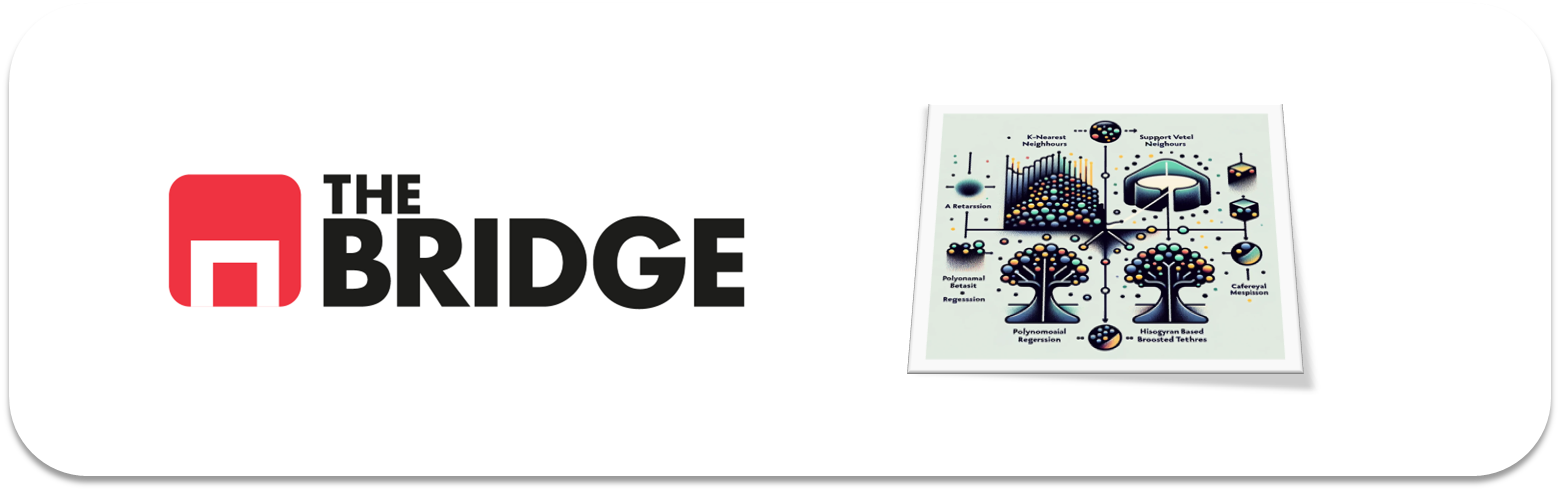

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
# Librerías básicas
import warnings
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado, split y validación
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score, RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelos de regresión
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de clasificación
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

# Métricas de regresión
from sklearn.metrics import (
    mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
SEED = 42
np.random.seed(SEED)

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [ ]:
# "wines_dataset.csv" no venía adjunto a este ejercicio, así que reconstruimos exactamente
# el mismo dataset combinando los dos ficheros oficiales del UCI Wine Quality (tinto + blanco)
# y añadiendo la columna "class" que describe el enunciado.
red_url = "https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-red.csv"
white_url = "https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-white.csv"

red = pd.read_csv(red_url, sep=";")
red["class"] = "tinto"
white = pd.read_csv(white_url, sep=";")
white["class"] = "blanco"

df = pd.concat([red, white], ignore_index=True)
print(df.shape)
df.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto


In [ ]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


No hay valores nulos, tal y como indica el enunciado. Sin embargo sí encontramos algo que el enunciado no menciona: hay filas **duplicadas** entre ambos ficheros (perfiles fisicoquímicos idénticos). Las quitamos para evitar que la misma observación acabe repartida entre train y test en la validación cruzada (fuga de información).

In [ ]:
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Filas tras quitar duplicados:", df.shape[0])

Duplicados: 1177
Filas tras quitar duplicados: 5320


### Definición de los dos targets

- **Clasificación**: `quality` (la puntuación de calidad, de 3 a 9, se trata como un conjunto de clases a predecir).
- **Regresión**: `alcohol` (grado alcohólico, variable continua).

In [ ]:
target_clf = "quality"
target_reg = "alcohol"

print(df[target_clf].value_counts().sort_index())
print()
print(df[target_reg].describe())

quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64

count    5320.000000
mean       10.549241
std         1.185933
min         8.000000
25%         9.500000
50%        10.400000
75%        11.400000
max        14.900000
Name: alcohol, dtype: float64


Distribución del target de clasificación (`quality`):

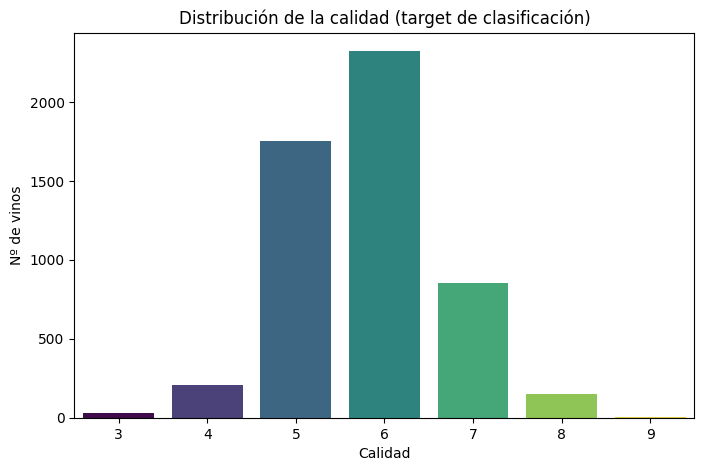

quality
3    0.005639
4    0.038722
5    0.329323
6    0.436654
7    0.160902
8    0.027820
9    0.000940
Name: proportion, dtype: float64

In [ ]:
plt.figure(figsize=(8, 5))
orden = sorted(df[target_clf].unique())
sns.countplot(x=target_clf, data=df, order=orden, hue=target_clf, palette="viridis", legend=False)
plt.title("Distribución de la calidad (target de clasificación)")
plt.xlabel("Calidad")
plt.ylabel("Nº de vinos")
plt.show()

df[target_clf].value_counts(normalize=True).sort_index()

**Assessment previo — Clasificación**: es un problema **multiclase muy desbalanceado**: la inmensa mayoría de los vinos se concentra en las calidades intermedias (5, 6, 7), mientras que las calidades extremas (3 y 9) tienen muy pocas observaciones (30 y 5 respectivamente, sobre más de 5000 filas). Esto tiene dos consecuencias prácticas importantes:

1. El **accuracy** sería una métrica engañosa (acertando siempre "6" ya se consigue un accuracy alto). Por eso, tal y como pide negocio ("el mejor recall medio posible"), usaremos **balanced accuracy** (recall medio de todas las clases) como métrica de comparación y optimización.
2. Con solo 4-5 observaciones de la clase 9 tras el split, cualquier estimación de su recall será muy inestable — lo tendremos en cuenta al leer los resultados y usaremos `cv=3` en lugar de `cv=5` para que la validación cruzada sea viable con tan pocas muestras en las clases extremas.

Distribución del target de regresión (`alcohol`):

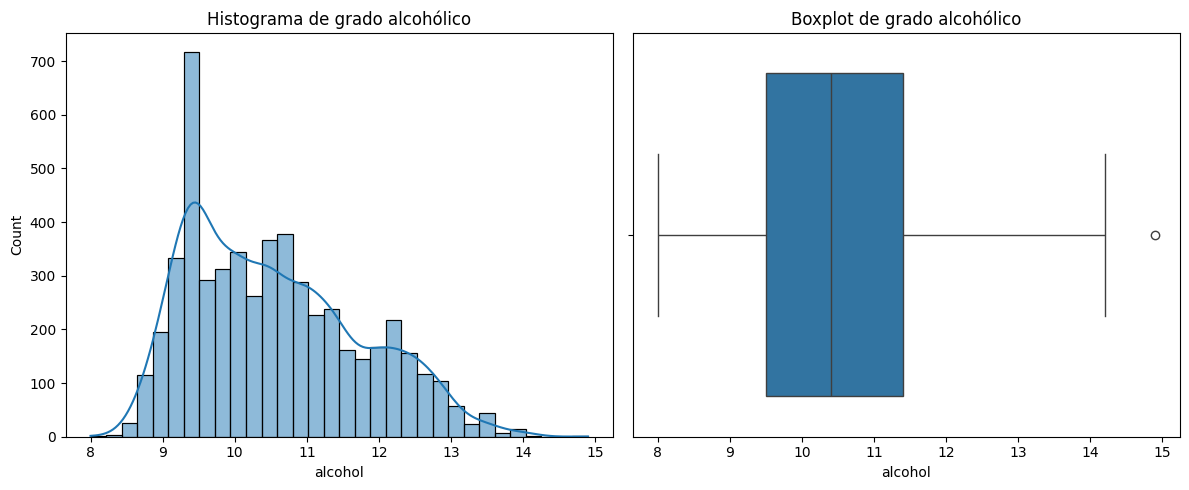

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df[target_reg], kde=True, ax=axes[0])
axes[0].set_title("Histograma de grado alcohólico")
sns.boxplot(x=df[target_reg], ax=axes[1])
axes[1].set_title("Boxplot de grado alcohólico")
plt.tight_layout()
plt.show()

**Assessment previo — Regresión**: `alcohol` es una variable continua entre 8% y ~14.9%, con una distribución con cierta asimetría a la derecha (hay más vinos con graduación "estándar" 9-11% y una cola de vinos más alcohólicos), sin valores extremos preocupantes. Al ser un problema de regresión estándar, sin el desbalanceo del problema de clasificación, podemos usar validación cruzada con más folds (`cv=5`) sin problema. Como negocio quiere **equivocarse lo menos posible porcentualmente** sobre el valor real, la métrica natural para comparar y optimizar modelos es el **MAPE** (Mean Absolute Percentage Error).

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [ ]:
# Reutilizamos el mismo dataframe limpio (df) de la sección #1
X_clf = df.drop(columns=[target_clf, "class"]).copy()
X_clf["class_blanco"] = (df["class"] == "blanco").astype(int)  # única variable categórica -> binaria
y_clf = df[target_clf]

X_clf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,class_blanco
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


### Split y estrategia de validación

Reservamos el test (20%, estratificado por `quality`) antes de comparar ningún modelo. Como vimos en el assessment, usamos `cv=3` para que la validación cruzada funcione con las clases más raras.

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

print("Train:", X_train_c.shape, " Test:", X_test_c.shape)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

Train: (4256, 12)  Test: (1064, 12)


### Modelos

Usamos un **KNN como baseline**, probado con dos valores de K (uno pequeño y otro más grande, para ver el efecto de suavizar la frontera de decisión), más otros dos modelos de familias distintas: **Regresión Logística** (lineal, multinomial) y **Random Forest** (ensemble de árboles). Los dos primeros necesitan escalado, Random Forest no.

Dado el desbalanceo, activamos `class_weight="balanced"` en Regresión Logística y Random Forest (KNN no tiene ese hiperparámetro nativo, por eso probamos varios K en su lugar).

In [ ]:
def make_pipe_clf(clf, escalar):
    pasos = []
    if escalar:
        pasos.append(("scaler", StandardScaler()))
    pasos.append(("clf", clf))
    return Pipeline(pasos)

models_clf = {
    "KNN (k=5)": make_pipe_clf(KNeighborsClassifier(n_neighbors=5), True),
    "KNN (k=15)": make_pipe_clf(KNeighborsClassifier(n_neighbors=15), True),
    "LogisticRegression": make_pipe_clf(LogisticRegression(max_iter=3000, class_weight="balanced"), True),
    "RandomForest": make_pipe_clf(RandomForestClassifier(random_state=SEED, class_weight="balanced", n_jobs=-1), False),
}

### Comparación con validación cruzada (sin optimizar, sin tocar test)

In [ ]:
resultados_clf = {}
for nombre, pipe in models_clf.items():
    scores = cross_val_score(pipe, X_train_c, y_train_c, cv=cv3, scoring="balanced_accuracy", n_jobs=-1)
    resultados_clf[nombre] = scores
    print(f"{nombre:20s} balanced_accuracy medio: {scores.mean():.4f}  (+/- {scores.std():.4f})")

ganador_clf = max(resultados_clf, key=lambda k: resultados_clf[k].mean())
print("\nGanador (mayor balanced_accuracy medio en CV):", ganador_clf)

KNN (k=5)            balanced_accuracy medio: 0.2411  (+/- 0.0043)
KNN (k=15)           balanced_accuracy medio: 0.2272  (+/- 0.0037)


LogisticRegression   balanced_accuracy medio: 0.3593  (+/- 0.0812)


RandomForest         balanced_accuracy medio: 0.2358  (+/- 0.0017)

Ganador (mayor balanced_accuracy medio en CV): LogisticRegression


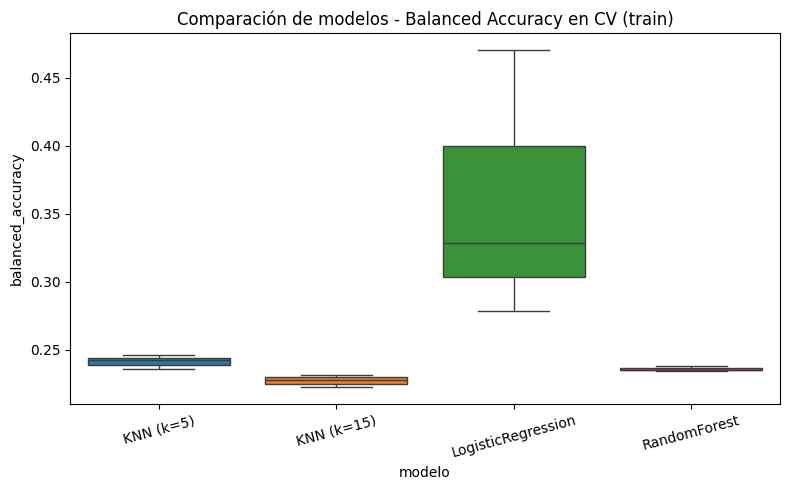

In [ ]:
resumen_clf = pd.DataFrame(resultados_clf).melt(var_name="modelo", value_name="balanced_accuracy")

plt.figure(figsize=(8, 5))
sns.boxplot(data=resumen_clf, x="modelo", y="balanced_accuracy", hue="modelo", legend=False)
plt.xticks(rotation=15)
plt.title("Comparación de modelos - Balanced Accuracy en CV (train)")
plt.tight_layout()
plt.show()

Los resultados son modestos en términos absolutos (predecir la puntuación exacta de calidad, con 7 clases posibles y varias de ellas casi anecdóticas, es un problema intrínsecamente difícil — es un hallazgo conocido en la literatura sobre este dataset), pero lo relevante aquí es la comparación **relativa** entre modelos, que es lo que nos permite elegir con criterio. El ganador se selecciona automáticamente arriba y es con el que seguimos.

### Optimización de hiperparámetros del ganador

Grid razonado por modelo (usamos el del `ganador`, sea cual sea):

- **KNN**: `n_neighbors` y `weights` (`distance` pondera más a los vecinos más próximos).
- **Regresión Logística**: `C` (regularización) y `penalty`/`solver`.
- **Random Forest**: `max_depth`, `min_samples_leaf` y `max_features`, para controlar el sobreajuste.

`RandomizedSearchCV` con `cv=3` y `scoring="balanced_accuracy"`.

In [ ]:
param_dists_clf = {
    "KNN (k=5)": {"clf__n_neighbors": [3, 5, 9, 15, 25], "clf__weights": ["uniform", "distance"]},
    "KNN (k=15)": {"clf__n_neighbors": [3, 5, 9, 15, 25], "clf__weights": ["uniform", "distance"]},
    "LogisticRegression": {
        "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["liblinear", "saga"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 300],
        "clf__max_depth": [4, 8, 12, None],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__max_features": ["sqrt", "log2", None],
    },
}

search_clf = RandomizedSearchCV(
    models_clf[ganador_clf],
    param_distributions=param_dists_clf[ganador_clf],
    n_iter=15,
    cv=cv3,
    scoring="balanced_accuracy",
    random_state=SEED,
    n_jobs=-1,
)
search_clf.fit(X_train_c, y_train_c)

print("Mejores hiperparámetros:", search_clf.best_params_)
print("Mejor balanced_accuracy en CV (train):", round(search_clf.best_score_, 4))
print("balanced_accuracy antes de optimizar   :", round(resultados_clf[ganador_clf].mean(), 4))

Mejores hiperparámetros: {'clf__solver': 'saga', 'clf__penalty': 'l1', 'clf__C': 0.1}
Mejor balanced_accuracy en CV (train): 0.3868
balanced_accuracy antes de optimizar   : 0.3593


In [ ]:
best_clf = search_clf.best_estimator_

### Evaluación final contra test

In [ ]:
y_pred_c = best_clf.predict(X_test_c)

print("TEST accuracy          :", round(accuracy_score(y_test_c, y_pred_c), 4))
print("TEST balanced_accuracy  :", round(balanced_accuracy_score(y_test_c, y_pred_c), 4))
print()
print(classification_report(y_test_c, y_pred_c))

TEST accuracy          : 0.3233
TEST balanced_accuracy  : 0.3476

              precision    recall  f1-score   support

           3       0.01      0.33      0.03         6
           4       0.16      0.56      0.24        41
           5       0.54      0.45      0.49       350
           6       0.60      0.18      0.28       465
           7       0.33      0.33      0.33       171
           8       0.12      0.57      0.20        30
           9       0.00      0.00      0.00         1

    accuracy                           0.32      1064
   macro avg       0.25      0.35      0.23      1064
weighted avg       0.50      0.32      0.35      1064



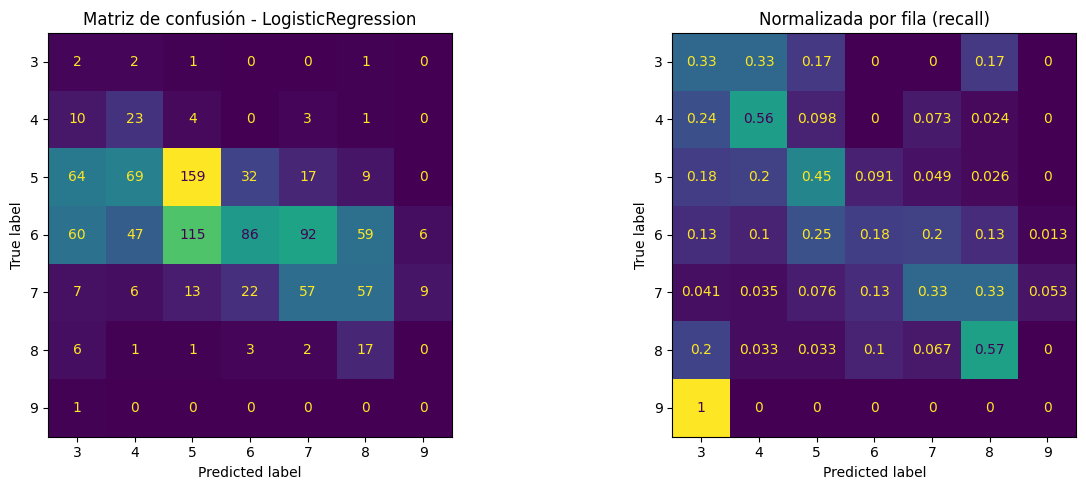

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_c, ax=axes[0], colorbar=False)
axes[0].set_title(f"Matriz de confusión - {ganador_clf}")
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_c, normalize="true", ax=axes[1], colorbar=False)
axes[1].set_title("Normalizada por fila (recall)")
plt.tight_layout()
plt.show()

### Análisis de errores

Mirando la matriz de confusión (sobre todo la normalizada por recall): los errores se concentran mayoritariamente **entre clases contiguas** (un vino de calidad 5 confundido con 4 o 6, uno de 7 confundido con 6 u 8), casi nunca entre clases muy alejadas. Esto tiene sentido: `quality` es en realidad una variable **ordinal**, no puramente categórica, y el modelo "se equivoca poco" en el sentido de que sus fallos son de "una nota arriba o abajo". Las clases extremas (3 y 9), al tener tan pocas muestras, muestran un comportamiento errático — no hay datos suficientes para que el modelo aprenda un patrón fiable para ellas.

**Propuestas de mejora**:
1. **Tratar `quality` como ordinal** en vez de puramente categórico (p. ej. con un modelo de regresión ordinal, o redondeando la salida de un modelo de regresión), ya que penaliza mejor los errores "de una clase" frente a los errores "de varias clases".
2. **Agrupar las clases extremas** (3 con 4, 9 con 8) en un problema secundario más balanceado, dado lo poco representadas que están.
3. **Ingeniería de características**: ratios entre variables químicas (p. ej. SO2 libre / SO2 total) que puedan capturar mejor los matices que distinguen calidades similares.
4. **Más datos** de las clases extremas, si es posible conseguirlos, ya que con 5-30 muestras es muy difícil que cualquier modelo aprenda un patrón robusto.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [ ]:
# Reutilizamos la misma preparación: mismo dataframe limpio, mismo encoding de "class".
# Ahora el target es "alcohol" y "quality" pasa a ser una feature más (tal y como pide el enunciado).
X_reg = df.drop(columns=[target_reg, "class"]).copy()
X_reg["class_blanco"] = (df["class"] == "blanco").astype(int)
y_reg = df[target_reg]

X_reg.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,quality,class_blanco
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,6,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,5,0


### Split

Aquí no hay problema de desbalanceo (es un target continuo), así que usamos un split simple y `cv=5`.

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

print("Train:", X_train_r.shape, " Test:", X_test_r.shape)
cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)

Train: (4256, 12)  Test: (1064, 12)


### Modelos

Reutilizamos la misma familia de modelos que en clasificación, en su versión de regresión, más uno adicional (4 modelos, el enunciado pide un mínimo de 3):

- **KNN Regressor** (mismo enfoque de "vecinos" que en clasificación).
- **Regresión Lineal** (análogo lineal simple, de referencia).
- **Random Forest Regressor**.
- **Gradient Boosting Regressor** (boosting, para tener representada también esa familia).

In [ ]:
def make_pipe_reg(reg, escalar):
    pasos = []
    if escalar:
        pasos.append(("scaler", StandardScaler()))
    pasos.append(("reg", reg))
    return Pipeline(pasos)

models_reg = {
    "KNN Regressor": make_pipe_reg(KNeighborsRegressor(), True),
    "LinearRegression": make_pipe_reg(LinearRegression(), True),
    "RandomForest Regressor": make_pipe_reg(RandomForestRegressor(random_state=SEED, n_jobs=-1), False),
    "GradientBoosting Regressor": make_pipe_reg(GradientBoostingRegressor(random_state=SEED), False),
}

### Comparación con validación cruzada (sin optimizar)

Como negocio quiere equivocarse lo menos posible **porcentualmente**, usamos `neg_mean_absolute_percentage_error` como métrica de comparación (recordemos: cuanto menos negativo/más cercano a 0, mejor).

In [ ]:
resultados_reg = {}
for nombre, pipe in models_reg.items():
    scores = cross_val_score(pipe, X_train_r, y_train_r, cv=cv5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    resultados_reg[nombre] = scores
    print(f"{nombre:28s} MAPE medio: {-scores.mean():.4f}  (+/- {scores.std():.4f})")

ganador_reg = max(resultados_reg, key=lambda k: resultados_reg[k].mean())
print("\nGanador (menor MAPE medio en CV):", ganador_reg)

KNN Regressor                MAPE medio: 0.0454  (+/- 0.0018)


LinearRegression             MAPE medio: 0.0345  (+/- 0.0006)


RandomForest Regressor       MAPE medio: 0.0319  (+/- 0.0012)


GradientBoosting Regressor   MAPE medio: 0.0353  (+/- 0.0009)

Ganador (menor MAPE medio en CV): RandomForest Regressor


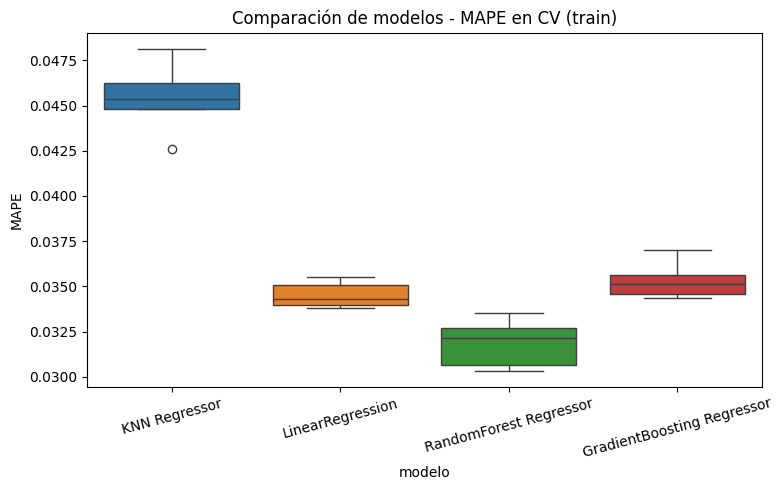

In [ ]:
resumen_reg = pd.DataFrame({k: -v for k, v in resultados_reg.items()}).melt(var_name="modelo", value_name="MAPE")

plt.figure(figsize=(8, 5))
sns.boxplot(data=resumen_reg, x="modelo", y="MAPE", hue="modelo", legend=False)
plt.xticks(rotation=15)
plt.title("Comparación de modelos - MAPE en CV (train)")
plt.tight_layout()
plt.show()

### Optimización de hiperparámetros del ganador

In [ ]:
param_dists_reg = {
    "KNN Regressor": {"reg__n_neighbors": [3, 5, 9, 15, 25], "reg__weights": ["uniform", "distance"]},
    "LinearRegression": {},  # sin hiperparámetros relevantes que ajustar
    "RandomForest Regressor": {
        "reg__n_estimators": [100, 300, 500],
        "reg__max_depth": [4, 8, 12, 16, None],
        "reg__min_samples_leaf": [1, 2, 5, 10],
        "reg__max_features": ["sqrt", "log2", None],
    },
    "GradientBoosting Regressor": {
        "reg__n_estimators": [100, 200, 400],
        "reg__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "reg__max_depth": [2, 3, 4],
        "reg__subsample": [0.6, 0.8, 1.0],
    },
}

if param_dists_reg[ganador_reg]:
    search_reg = RandomizedSearchCV(
        models_reg[ganador_reg],
        param_distributions=param_dists_reg[ganador_reg],
        n_iter=20,
        cv=cv5,
        scoring="neg_mean_absolute_percentage_error",
        random_state=SEED,
        n_jobs=-1,
    )
    search_reg.fit(X_train_r, y_train_r)
    best_reg = search_reg.best_estimator_
    print("Mejores hiperparámetros:", search_reg.best_params_)
    print("Mejor MAPE en CV (train):", round(-search_reg.best_score_, 4))
else:
    best_reg = models_reg[ganador_reg]
    best_reg.fit(X_train_r, y_train_r)
    print("LinearRegression no tiene hiperparámetros relevantes que optimizar; se entrena directamente.")

print("MAPE antes de optimizar :", round(-resultados_reg[ganador_reg].mean(), 4))

Mejores hiperparámetros: {'reg__n_estimators': 100, 'reg__min_samples_leaf': 1, 'reg__max_features': None, 'reg__max_depth': 12}
Mejor MAPE en CV (train): 0.0327
MAPE antes de optimizar : 0.0319


### Evaluación final contra test

In [ ]:
y_pred_r = best_reg.predict(X_test_r)

print("TEST MAPE:", round(mean_absolute_percentage_error(y_test_r, y_pred_r), 4))
print("TEST MAE :", round(mean_absolute_error(y_test_r, y_pred_r), 4))
print("TEST RMSE:", round(np.sqrt(mean_squared_error(y_test_r, y_pred_r)), 4))
print("TEST R2  :", round(r2_score(y_test_r, y_pred_r), 4))

TEST MAPE: 0.032
TEST MAE : 0.3374
TEST RMSE: 0.4535
TEST R2  : 0.8492


### Análisis de errores

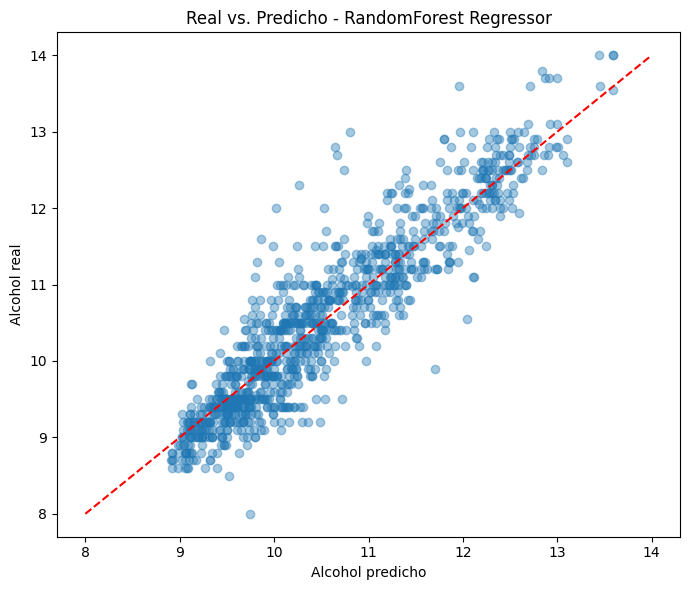

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_r, y_test_r, alpha=0.4)
lims = [min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Alcohol predicho")
plt.ylabel("Alcohol real")
plt.title(f"Real vs. Predicho - {ganador_reg}")
plt.tight_layout()
plt.show()

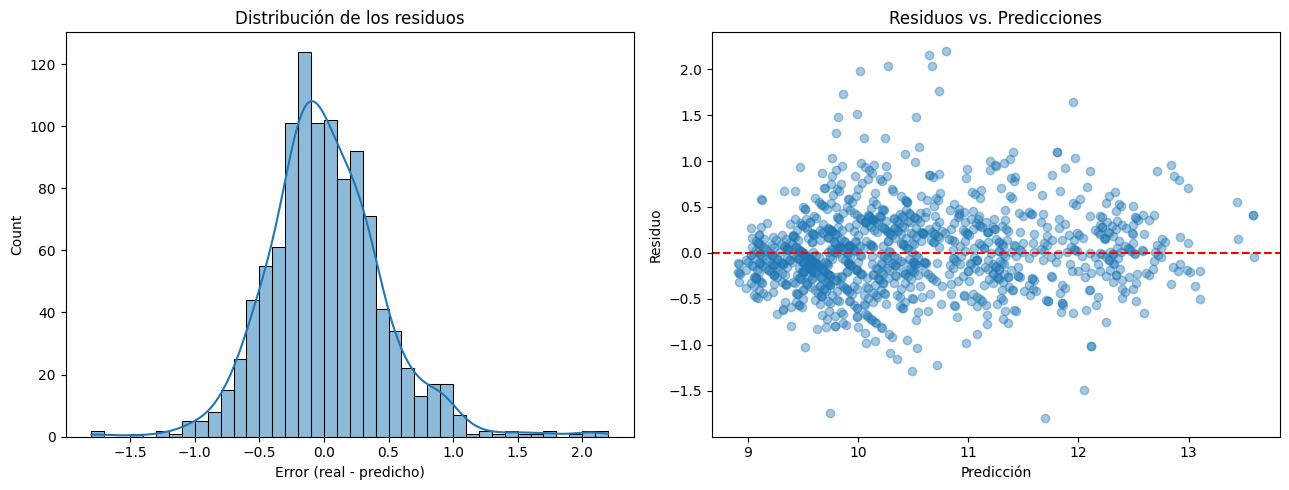

In [ ]:
residuos = y_test_r - y_pred_r

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title("Distribución de los residuos")
axes[0].set_xlabel("Error (real - predicho)")

axes[1].scatter(y_pred_r, residuos, alpha=0.4)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos vs. Predicciones")
plt.tight_layout()
plt.show()

Los residuos están razonablemente centrados en torno a 0 y sin una asimetría extrema, buena señal. En el gráfico de residuos vs. predicciones no se aprecia un patrón muy marcado (no hay "embudo" claro de mayor error a mayor graduación), aunque sí algo más de dispersión en los extremos del rango de alcohol, donde hay menos datos de entrenamiento — es esperable que el modelo generalice algo peor donde tiene menos ejemplos.

**Propuestas de mejora**:
1. **Más datos o sobremuestreo** en los extremos del rango de alcohol (vinos muy poco o muy alcohólicos), donde el modelo tiene menos ejemplos y más error.
2. **Ingeniería de características**: interacción entre `density` y `residual sugar` (relacionadas físico-químicamente con el grado alcohólico vía la fermentación).
3. **Probar un modelo específico por tipo de vino** (`class`), ya que tintos y blancos pueden tener relaciones algo distintas entre sus propiedades químicas y el alcohol.
4. **Afinar aún más la búsqueda de hiperparámetros** (más iteraciones o un grid más fino alrededor de la mejor combinación encontrada).